In [1]:
import torch
import torch.utils.data
import time
import numpy as np
import random
import os
import matplotlib.pyplot as plt
from alive_progress import alive_bar
from sklearn.preprocessing import StandardScaler # Import StandardScaler
import sys 

sys.path.append(r"H:\Projects\Edit-Novel-Seq2Seq-Module-master")

# فراخوانی کلاس DataPrepare از ماژول preparedata
import prepare_data.prepare_data as prepare_data
from prepare_data.prepare_data import DataPrepare
from Novel_Seq2Seq.model import stack


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

DEVICE: cpu


h:\Projects\Edit-Novel-Seq2Seq-Module-master\.venv\Lib\site-packages\torch\__init__.py:1275: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\tensor\python_tensor.cpp:436.)
  _C._set_default_tensor_type(t)


In [2]:
print(prepare_data.__file__)


H:\Projects\Edit-Novel-Seq2Seq-Module-master\prepare_data\prepare_data.py


In [2]:
class MyMetrics:
    def __init__(self, y_pred, y_true, un_std):

        self.un_std = un_std
        self.y_pred = y_pred
        self.y_true = y_true
        self.metrics = {}
        self.mse()
        self.mape()
        self.smape()

    def mse(self):
        self.metrics['mse'] = np.mean((self.y_pred - self.y_true) ** 2)

    def mape(self):
        y_pred = self.un_std.un_standardize(x=self.y_pred)
        y_true = self.un_std.un_standardize(x=self.y_true)
        self.metrics['mape'] = np.mean(np.abs((y_pred - y_true) / (y_true))) * 100

    def smape(self):
        self.metrics['smape'] = 2.0 * np.mean(
            np.abs(self.y_pred - self.y_true) / (np.abs(self.y_pred) + np.abs(self.y_true))
        ) * 100

    def print_metrics(self):
        for key, values in self.metrics.items():
            print(f"The {key} is:{values}.")


In [4]:
class Train:
    def __init__(self, hyperparams, model, optimizer, loss_func):
        # پارامترهای دیتاست
        self.datapath       = hyperparams['datapath']
        self.datafile       = hyperparams['datafile']
        self.split_ratio    = hyperparams['split_ratio']

        # هایپرپارامترها
        self.N_EPOCHS       = hyperparams['N_EPOCHS']
        self.lr             = hyperparams['lr']
        self.batch_size     = hyperparams['batch_size']
        self.input_seqlen   = hyperparams['input_seqlen']
        self.predict_seqlen = hyperparams['predict_seqlen']
        self.features       = hyperparams['features']

        # آماده‌سازی داده
        self.dataprepare =  DataPrepare(
            datapath      = self.datapath,
            datafile      = self.datafile,
            input_steps   = self.input_seqlen,
            pred_horizion = self.predict_seqlen,
            split_ratio   = self.split_ratio
        )

        # دیتالودرها
        self.train_generator = None
        self.valid_generator = None
        self.test_generator  = None

        # مدل/بهینه‌ساز/تابع ضرر
        self.model     = model
        self.optimizer = optimizer
        self.loss_func = loss_func

        # loss تاریخچه‌ی توابع
        self.train_loss = []
        self.valid_loss = []
        self.mse        = 0

        #  مسیر ذخیره
        self.save_dir = os.path.join(os.getcwd(), "trained_file")
        os.makedirs(self.save_dir, exist_ok=True)

        # seed
        self._setup_seed(20)

        # ساخت دیتالودرها
        self._prepare_data()


#DataPrepare → داده خام رو می‌خونه، تمیز می‌کنه و تقسیم می‌کنه
#Datasets →  تبدیل می‌کنهPyTorch  داده رو به فرمت
#DataLoader → داده رو دسته‌بندی می‌کنه برای آموزش

    def _prepare_data(self):
        # خروجی prepare_data: (train_ip, train_op, valid_ip, valid_op, test_ip, test_op)
        tvt_data = self.dataprepare.prepare_data()
        self.dataprepare.train_data = tvt_data[0] # Store train_data as attribute
        train_dataset = prepare_data.Datasets(tvt_data[0], tvt_data[1])
        valid_dataset = prepare_data.Datasets(tvt_data[2], tvt_data[3])
        test_dataset  = prepare_data.Datasets(tvt_data[4], tvt_data[5])

        self.train_generator = torch.utils.data.DataLoader(train_dataset, batch_size=self.batch_size, shuffle=False)
        self.valid_generator = torch.utils.data.DataLoader(valid_dataset, batch_size=self.batch_size, shuffle=False)
        self.test_generator  = torch.utils.data.DataLoader(test_dataset,  batch_size=2048, shuffle=False)

    def _ckpt_path(self):
        # نام فایل چک‌پوینت
        name = f'{self.datafile}-{self.input_seqlen}to{self.predict_seqlen}.pt'
        return os.path.join(self.save_dir, name)

    #def save_state(self, state):
        #torch.save(state, self._ckpt_path())

    #def load_state(self):
        #print("Loading model and optimizer state")
        #state = torch.load(self._ckpt_path(), map_location="cpu")
        #self.model.load_state_dict(state['model'])
        #self.optimizer.load_state_dict(state['optimizer'])
        #self.train_loss = state['train_loss']
        #self.valid_loss = state['valid_loss']
        #self.mse        = state['mse']
        #self.dataprepare= state['dataprepare']

    def save_state(self, state, filename=None):
        filepath = self._ckpt_path()
        state["epoch"] = state.get("epoch", 0)   # شماره ایپاک هم ذخیره کن
        torch.save(state, filepath)
        print(f"Checkpoint saved to {filepath}")

    def load_state(self, filename=None):
        filepath = self._ckpt_path()
        print(f"Loading checkpoint from {filepath}")
        state = torch.load(filepath, map_location=DEVICE, weights_only=False)
        self.model.load_state_dict(state['model'])
        self.optimizer.load_state_dict(state['optimizer'])
        self.train_loss = state['train_loss']
        self.valid_loss = state['valid_loss']
        self.mse        = state['mse']
        # Re-run data preparation to ensure train_data is available for scaler
        self._prepare_data()
        self.start_epoch = state.get("epoch_saved", 0)

    def _train(self):
        """
        params:
                None
        returns:
            每个样本的平均损失值
        """
        self.model.train()
        epoch_loss = 0

        for i, (x, y) in enumerate(self.train_generator):
            x = x.to(DEVICE)  # [batch_size, seq_len, feature]
            y = y.to(DEVICE)  # [batch_size, predict_seqlen]

            self.optimizer.zero_grad()
            # 输入到模型的是[batch_size, seq_len, features],模型输出是[batch_size,predict_seqlen, 1]
            output, residual = self.model(x)
            loss = self.loss_func(output.squeeze(dim=2), y) # + torch.mean(torch.abs(residual)) # output [batch_size, predict_seqlen]
            loss.backward()
            self.optimizer.step()
            epoch_loss += loss.item()
        # len(train_generator) 是 批次数量  即 样本总数/batch_size
        return epoch_loss / len(self.train_generator)



    def _evalute(self):
        self.model.eval()
        epoch_loss = 0.0
        with torch.no_grad():       #چوتن در پای تورچ گرادیان ها با گرادیان قبلی جمع میشود
            for x, y in self.test_generator:
                x = x.to(DEVICE)
                y = y.to(DEVICE)
                output, _ = self.model(x)  # [B, pred_len, 1]
                loss = self.loss_func(output.squeeze(2), y)
                epoch_loss += loss.item()
        return epoch_loss / len(self.test_generator)

    def _epoch_time(self, start_time, end_time):
        elapsed = end_time - start_time
        return int(elapsed // 60), int(elapsed % 60)
# قابلیت تکرارپذیری نتایج
    def _setup_seed(self, seed):
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        np.random.seed(seed)
        random.seed(seed)
        torch.backends.cudnn.deterministic = True

    def train_model(self):
        best_valid_loss = float('inf')
        start_epoch = getattr(self, "start_epoch", 0)   # اگر load_state شده باشه از ادامه شروع کن
        print(f'DEVICE: {DEVICE}')

        with alive_bar(total=self.N_EPOCHS, title='training') as bar:
            for epoch in range(start_epoch, self.N_EPOCHS):
              start_time = time.time()

              train_loss = self._train()
              valid_loss = self._evalute()

              self.train_loss.append(train_loss)
              self.valid_loss.append(valid_loss)

              epoch_mins, epoch_secs = self._epoch_time(start_time, time.time())

            # ذخیره بهترین مدل
              if best_valid_loss > valid_loss:
                best_valid_loss = valid_loss
                self.mse = valid_loss
                state = {
                    'model'      : self.model.state_dict(),
                    'optimizer'  : self.optimizer.state_dict(),
                    'train_loss' : self.train_loss,
                    'valid_loss' : self.valid_loss,
                    'dataprepare': self.dataprepare,
                    'mse'        : self.mse,
                    'epoch_saved': epoch + 1
                }
                self.save_state(state, filename=f"{self.datafile}-{self.input_seqlen}to{self.predict_seqlen}-best.pt")
                print(f"✅ Best model updated at epoch {epoch+1} | Val Loss: {valid_loss:.4f}")

            # ذخیره آخرین ایپاک (همیشه)
              last_state = {
                'model'      : self.model.state_dict(),
                'optimizer'  : self.optimizer.state_dict(),
                'train_loss' : self.train_loss,
                'valid_loss' : self.valid_loss,
                'dataprepare': self.dataprepare,
                'mse'        : valid_loss,
                'epoch_saved': epoch + 1
              }
              self.save_state(last_state, filename=f"{self.datafile}-{self.input_seqlen}to{self.predict_seqlen}-last.pt")

              print(f'Epoch: {epoch + 1:02} | Time: {epoch_mins}m {epoch_secs}s')
              print(f'\tTrain MSE_Loss: {train_loss:.4f}')
              print(f'\t Val. MSE_Loss: {valid_loss:.4f}')
              bar()



    def plot_loss(self, save: bool = False):
        fig = plt.figure(figsize=(15, 8), dpi=80)
        ax1 = fig.add_subplot(1, 1, 1)
        ax1.set_title('loss_value')
        ax1.set_xlabel('epoch')
        ax1.set_ylabel('loss')
        ax1.set_xlim(0, self.N_EPOCHS)
        ax1.plot(self.train_loss, marker='o', label='train_loss')
        ax1.plot(self.valid_loss, linestyle='--', alpha=0.7, label='valid_loss')
        ax1.legend(loc='upper left')
        if save:
            plt.savefig('loss_value.jpg', dpi=400, bbox_inches='tight')
        plt.show()

    def predict(self):
        """
        :return: y_hat, y  → هر کدام [samples, pred_len]
        """
        self.model.eval()
        with torch.no_grad():
            for x, y in self.test_generator:
                x = x.to(DEVICE)
                y = y.to(DEVICE)
                y_hat, _ = self.model(x)              # [B, pred_len, 1]
                y_hat = y_hat.squeeze(2)              # [B, pred_len]
                break
        return y_hat.cpu().numpy(), y.cpu().numpy()

In [17]:
# هایپرپارامترها (طبق مقاله مقادیر H=3/6/12/24 را تغییر بده)
HyperParams = {
    'datapath'       : r"H:/Projects/Edit-Novel-Seq2Seq-Module-master/prepare_data/data",
    'datafile'       : 'AT_data_features',
    'split_ratio'    : (0.8, 0.1, 0.1),
    'N_EPOCHS'       : 50,                 # برای تست سریع؛ بعداً بیشترش کن
    'lr'             : 1e-3,
    'batch_size'     : 64,
    'input_seqlen'   : 24,
    'predict_seqlen' : 12,
    'features'       : 14,                 # LOAD, TEMP, WIND,SIN_HOUR,COS_HOUR,...
}


def main(LOAD_PREV=True):

    # ساخت مدل مطابق کد اصلی (stack.Stack)
    model = stack.Stack(
        input_size      = HyperParams['features'],
        encoder_channels= [4,6,8,12],
        input_seqlen    = HyperParams['input_seqlen'],
        forecast_seqlen = HyperParams['predict_seqlen']
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=HyperParams['lr'])
    loss_func = torch.nn.MSELoss(reduction='mean')

    T = Train(hyperparams=HyperParams, model=model, optimizer=optimizer, loss_func=loss_func)


    if LOAD_PREV:
        print("🔄 Loading checkpoint and continuing training...")
        T.load_state()
        # Refit the scaler after loading the state
        T.dataprepare.scaler_load.fit(T.dataprepare.train_data[:, 0].reshape(-1, 1))
        T.train_model()

    else:
        print("🆕 Starting training from scratch...")
        T.train_model()

    # ارزیابی
    y_hat, y = T.predict()
    metrics = MyMetrics(y_hat, y, T.dataprepare)
    metrics.print_metrics()
    T.plot_loss()

In [18]:
# فهمیدن تعداد بلوک ها
ckpt = r"H:/Projects/Edit-Novel-Seq2Seq-Module-master/trained_file/AT_data_features-24to12.pt"
state = torch.load(ckpt, map_location="cpu", weights_only=False)  # حتماً False

sd = state["model"]  # state_dictِ مدل
blocks = sorted({k.split('.')[0] for k in sd.keys() if k.startswith('block_')})
print(blocks)  # مثلا ['block_1', 'block_2']

h:\Projects\Edit-Novel-Seq2Seq-Module-master\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


['block_1', 'block_2', 'block_3']


h:\Projects\Edit-Novel-Seq2Seq-Module-master\.venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


🔄 Loading checkpoint and continuing training...
Loading checkpoint from h:\Projects\Edit-Novel-Seq2Seq-Module-master\Novel_Seq2Seq\trained_file\AT_data_features-24to12.pt
DEVICE: cpu
training |⚠︎                                       | (!) 0/50 [0%] in 0.0s (0.00/s) 
The mse is:0.003102289149660886.
The mape is:8.426697869350459.
The smape is:8.237700586955748.


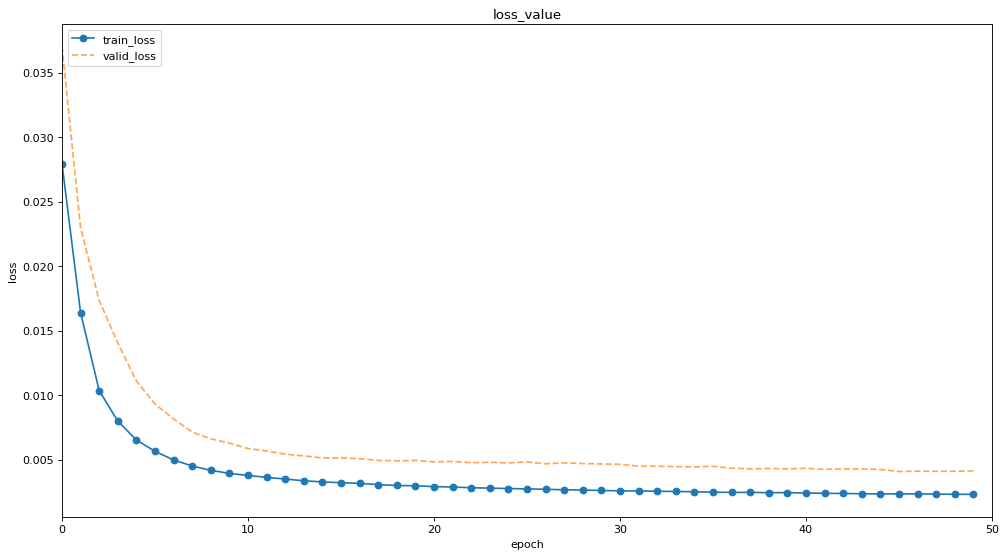

In [19]:
main()
